In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

In [44]:
forest_df = pd.read_csv("API_AG.csv", skiprows=4)

forest_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,Forest area (% of land area),AG.LND.FRST.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.333333,2.333333,2.333333,2.333333,2.333333,2.333333,2.333333,2.333333,NaN,NaN
1,Africa Eastern and Southern,AFE,Forest area (% of land area),AG.LND.FRST.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,31.039682,30.824316,30.611512,30.391626,30.174252,29.955194,29.737205,NaN,NaN,NaN
2,Afghanistan,AFG,Forest area (% of land area),AG.LND.FRST.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,1.852782,1.852782,1.852782,1.852782,1.852782,1.852782,1.852782,1.852782,NaN,NaN
3,Africa Western and Central,AFW,Forest area (% of land area),AG.LND.FRST.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,20.152610,20.071327,19.986100,19.901230,19.816784,19.732037,19.647488,NaN,NaN,NaN
4,Angola,AGO,Forest area (% of land area),AG.LND.FRST.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,55.207845,54.762629,54.317406,53.872175,53.426951,52.981722,52.536497,52.091270,NaN,NaN


In [45]:
# ülke bilgileri
country_meta = pd.read_csv("Metadata_Indicator.csv")
country_meta.head()

,INDICATOR_CODE,INDICATOR_NAME,SOURCE_NOTE,SOURCE_ORGANIZATION,Unnamed: 4
0,AG.LND.FRST.ZS,Forest area (% of land area),Forest area (% of land area) is the share of t...,"FAOSTAT, Food and Agriculture Organization of ...",NaN


In [46]:
indicator_meta = pd.read_csv("Metadata_Country.csv")
indicator_meta.head()

,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
0,ABW,Latin America & Caribbean,High income,NaN,Aruba,NaN
1,AFE,NaN,NaN,"26 countries, stretching from the Red Sea in t...",Africa Eastern and Southern,NaN
2,AFG,Middle East & North Africa,Low income,The reporting period for national accounts dat...,Afghanistan,NaN
3,AFW,NaN,NaN,"22 countries, stretching from the westernmost ...",Africa Western and Central,NaN
4,AGO,Sub-Saharan Africa,Lower middle income,The World Bank systematically assesses the app...,Angola,NaN


In [47]:
print("Forest data:", forest_df.shape)
print("Country meta:", country_meta.shape)
print("Indicator meta:", indicator_meta.shape)
forest_df.head()

Forest data: (266, 70)
Country meta: (1, 5)
Indicator meta: (265, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,Forest area (% of land area),AG.LND.FRST.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.333333,2.333333,2.333333,2.333333,2.333333,2.333333,2.333333,2.333333,NaN,NaN
1,Africa Eastern and Southern,AFE,Forest area (% of land area),AG.LND.FRST.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,31.039682,30.824316,30.611512,30.391626,30.174252,29.955194,29.737205,NaN,NaN,NaN
2,Afghanistan,AFG,Forest area (% of land area),AG.LND.FRST.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,1.852782,1.852782,1.852782,1.852782,1.852782,1.852782,1.852782,1.852782,NaN,NaN
3,Africa Western and Central,AFW,Forest area (% of land area),AG.LND.FRST.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,20.152610,20.071327,19.986100,19.901230,19.816784,19.732037,19.647488,NaN,NaN,NaN
4,Angola,AGO,Forest area (% of land area),AG.LND.FRST.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,55.207845,54.762629,54.317406,53.872175,53.426951,52.981722,52.536497,52.091270,NaN,NaN


In [48]:
# 1. Sütun adlarını temizle 
forest_df.columns = forest_df.columns.str.strip()

# 2. "Unnamed" sütunları kaldır
forest_df = forest_df.loc[:, ~forest_df.columns.str.contains('^Unnamed')]

# geniş fomattan uzun formata dönüştür 
forest_long = forest_df.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="Year",
    value_name="Forest_Area"
)    

# 4. year sütununu sayısala çevir ve eksik değerleri kaldır
forest_long["Year"] = pd.to_numeric(forest_long["Year"], errors="coerce")
forest_long.dropna(subset=["Forest_Area", "Year"], inplace=True)

forest_long.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Forest_Area
7980,Aruba,ABW,Forest area (% of land area),AG.LND.FRST.ZS,1990,2.333333
7981,Africa Eastern and Southern,AFE,Forest area (% of land area),AG.LND.FRST.ZS,1990,42.975250
7982,Afghanistan,AFG,Forest area (% of land area),AG.LND.FRST.ZS,1990,1.852782
7983,Africa Western and Central,AFW,Forest area (% of land area),AG.LND.FRST.ZS,1990,22.776908
7984,Angola,AGO,Forest area (% of land area),AG.LND.FRST.ZS,1990,63.578070


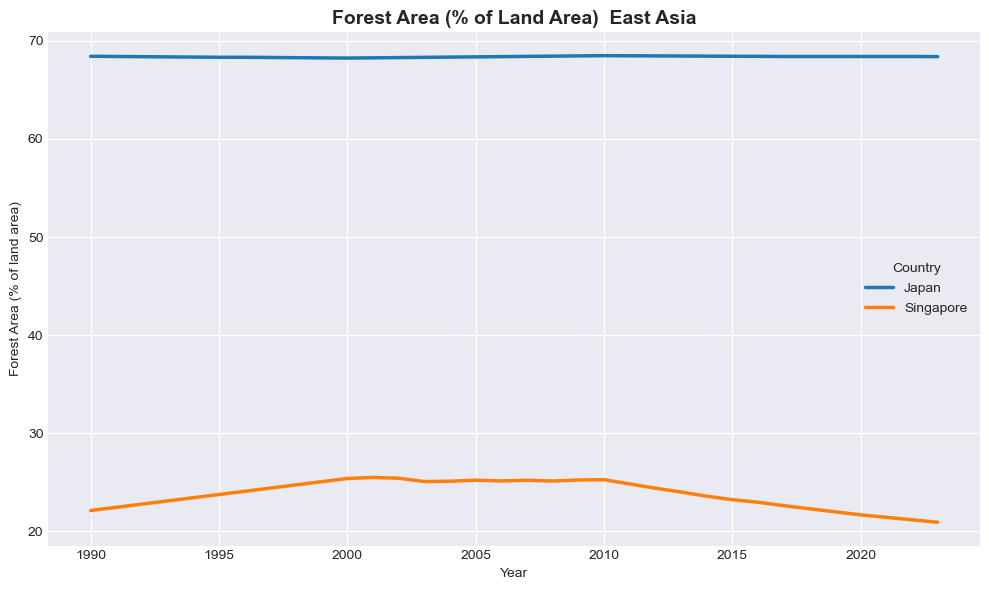

In [49]:
# Grafik stili
plt.style.use("seaborn-v0_8-darkgrid")

# filtreleme
selected_countries = ["Japan", "Taiwan", "Singapore"]
filtered_df = forest_long[forest_long["Country Name"].isin(selected_countries)]

# grafik çizimi
plt.figure(figsize=(10,6))
sns.lineplot(data=filtered_df, x="Year", y="Forest_Area", hue="Country Name", linewidth=2.5)

plt.title("Forest Area (% of Land Area)  East Asia", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Forest Area (% of land area)")
plt.legend(title="Country", loc="best")
plt.tight_layout()
plt.show()           

In [50]:
# Japonya verisini filtrele
japan_data = forest_long[forest_long["Country Name"] == "Japan"]

In [51]:
# Gerekli sütunları seç
X = japan_data[["Year"]]
y = japan_data["Forest_Area"]

In [52]:
# modeli oluştur ve eğit
model = LinearRegression()
model.fit(X, y)


LinearRegression()

In [53]:
# tahmin yapmak için yeni yıllar oluştur 2023-2030
future_years = np.arange(2023, 2031).reshape(-1, 1)
future_pred = model.predict(future_years)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


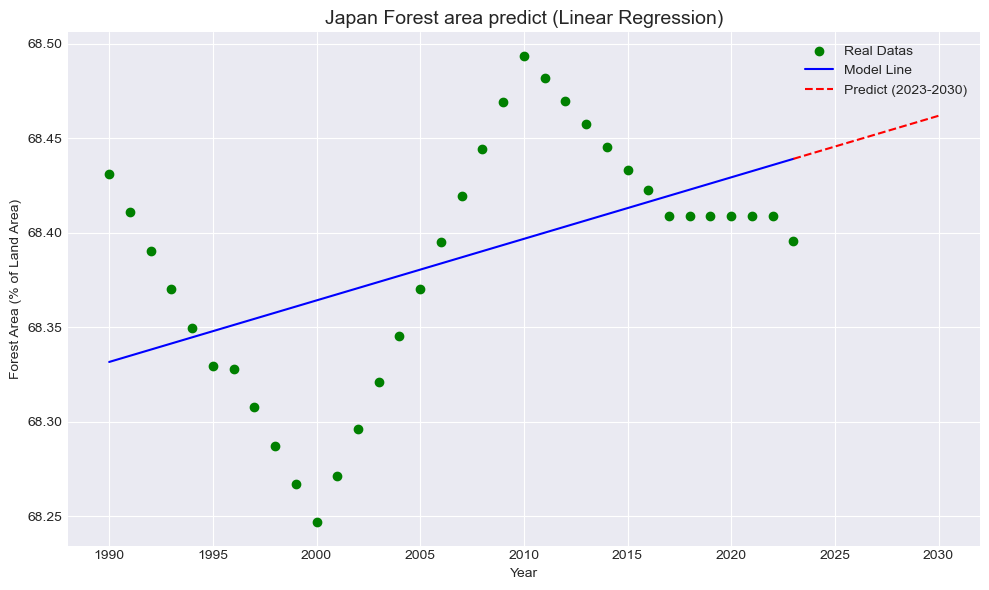

In [54]:
# görselleştirme
plt.figure(figsize=(10,6))
plt.scatter(X, y, color="green", label="Real Datas")
plt.plot(X, model.predict(X), color="blue", label="Model Line")
plt.plot(future_years, future_pred, color="red", linestyle="--", label="Predict (2023-2030)")

plt.title("Japan Forest area predict (Linear Regression)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Forest Area (% of Land Area)")
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
# gelecek yılların tahminlerini göster
future_df = pd.DataFrame({
    "Year": future_years.flatten(),
    "Predicted_Forest_Area": future_pred
})

print(future_df)    

   Year  Predicted_Forest_Area
0  2023              68.439215
1  2024              68.442472
2  2025              68.445729
3  2026              68.448985
4  2027              68.452242
5  2028              68.455499
6  2029              68.458756
7  2030              68.462012
